### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [21]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('drive/MyDrive/Colab Notebooks/marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Year_Birth            2239 non-null   int64
 1   Income                2239 non-null   int64
 2   Kidhome               2239 non-null   int64
 3   Teenhome              2239 non-null   int64
 4   Recency               2239 non-null   int64
 5   MntWines              2239 non-null   int64
 6   MntFruits             2239 non-null   int64
 7   MntMeatProducts       2239 non-null   int64
 8   MntFishProducts       2239 non-null   int64
 9   MntSweetProducts      2239 non-null   int64
 10  MntGoldProds          2239 non-null   int64
 11  NumDealsPurchases     2239 non-null   int64
 12  NumWebPurchases       2239 non-null   int64
 13  NumCatalogPurchases   2239 non-null   int64
 14  NumStorePurchases     2239 non-null   int64
 15  NumWebVisitsMonth     2239 non-null   int64
 16  Accept

In [12]:
key_features = ["Income",
                "Recency",
                "NumStorePurchases",
                "NumDealsPurchases",
                "days_lifetime",
                "years_customer",
                "NumWebVisitsMonth"]

In [13]:
X[key_features][:5]

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,58138,58,4,3,663,57,7
1,46344,38,2,2,113,60,5
2,71613,26,10,1,312,49,4
3,26646,26,4,2,139,30,6
4,58293,94,6,5,161,33,5


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[key_features] = scaler.fit_transform(X[key_features])

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state= 42)
label = kmeans.fit_predict(X[key_features])

In [27]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X[key_features])

df_pca = pd.DataFrame(
    X_pca,
    columns= ["PC1","PC2","PC3"]
)
print(df_pca)

df_pca["Cluster"] = label

               PC1         PC2        PC3
0      6725.150528  310.933459   7.882524
1     -5068.727715 -241.742384 -10.106719
2     20200.227281  -37.201380 -22.941061
3    -24766.735666 -220.084816 -22.492374
4      6880.258787 -190.867428  45.438476
...            ...         ...        ...
2234   9810.211615   29.576553  -3.204954
2235  12601.293216 -331.770825   8.291682
2236   5568.260763 -197.158081  42.458488
2237  17832.262701 -193.795677 -40.288299
2238   1456.160073  268.705867  -9.936739

[2239 rows x 3 columns]


In [28]:
import plotly.express as px

fig = px.scatter_3d(
    df_pca,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    opacity=0.7,
    symbol="Cluster",
    title="3D розподіл клієнтів у просторі головних компонент"
)

fig.show()


Кластеризація вийшла погано розділена, кластер два взагалі розсіяний серед кластеру 1.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [30]:
import numpy as np

print("Частка поясненої дисперсії для кожної компоненти:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])

print("Сумарно:", pca.explained_variance_ratio_.sum())


Частка поясненої дисперсії для кожної компоненти:
PC1: 0.9999141079834248
PC2: 8.385962564374537e-05
PC3: 1.7212779125954496e-06
Сумарно: 0.9999996888869812


In [31]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Кумулятивна частка поясненої дисперсії:", cumulative_variance)

Кумулятивна частка поясненої дисперсії: [0.99991411 0.99999797 0.99999969]


### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [32]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=key_features
)

print(loadings.head())


                        PC1       PC2           PC3
Income             1.000000  0.000220 -5.456076e-07
Recency           -0.000001  0.003597  9.999402e-01
NumStorePurchases  0.000091  0.002019 -2.218046e-04
NumDealsPurchases -0.000009  0.002066 -4.008704e-04
days_lifetime     -0.000220  0.999984 -3.577022e-03


PC1 ≈ Income (1.0)\
PC2 ≈ days_lifetime (≈1.0)\
PC3 ≈ Recency (≈1.0)\
Це означає, що кожна компонента прив’язана майже до однієї змінної. Але при цьому тільки Income реально має варіацію, яка пояснює дані, а інші змінні додають дуже мало.

Виходить що у нас дані лежать майже на одній осі і тому кластеризація вийшла погана, бо одна ознака описує майже 100 відсотків дисперсії.

###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [35]:
from sklearn.manifold import TSNE
t_sne = TSNE(n_components=2, random_state=0)

X_tnse = t_sne.fit_transform(X[key_features])

In [36]:
df_tsne= pd.DataFrame(
    X_tnse,
    columns=["TSNE1", "TSNE2"]
)
df_tsne["Cluster"] = label

print(df_tsne.head())

       TSNE1      TSNE2  Cluster
0   9.018298  48.445530        2
1  -9.323896 -47.982384        0
2  22.625341 -14.521701        1
3 -40.530624  10.376587        0
4   9.900537  46.953728        2


In [37]:
fig = px.scatter(
    df_tsne,
    x="TSNE1", y="TSNE2",
    color="Cluster",
    opacity=0.7,
    title="Розподіл клієнтів у просторі t-SNE"
)
fig.show()


In [38]:
cluster_profile = X.groupby(df_tsne["Cluster"])[key_features].mean()
print(cluster_profile)


               Income    Recency  NumStorePurchases  NumDealsPurchases  \
Cluster                                                                  
0        33061.005203  48.509886           3.176899           1.811655   
1        72551.554070  49.345079           8.341434           1.442284   
2        51937.723077  50.006593           6.701099           5.002198   

         days_lifetime  years_customer  NumWebVisitsMonth  
Cluster                                                    
0           312.302810       41.919875           6.506764  
1           315.252734       47.347509           3.066829  
2           510.013187       48.232967           6.870330  


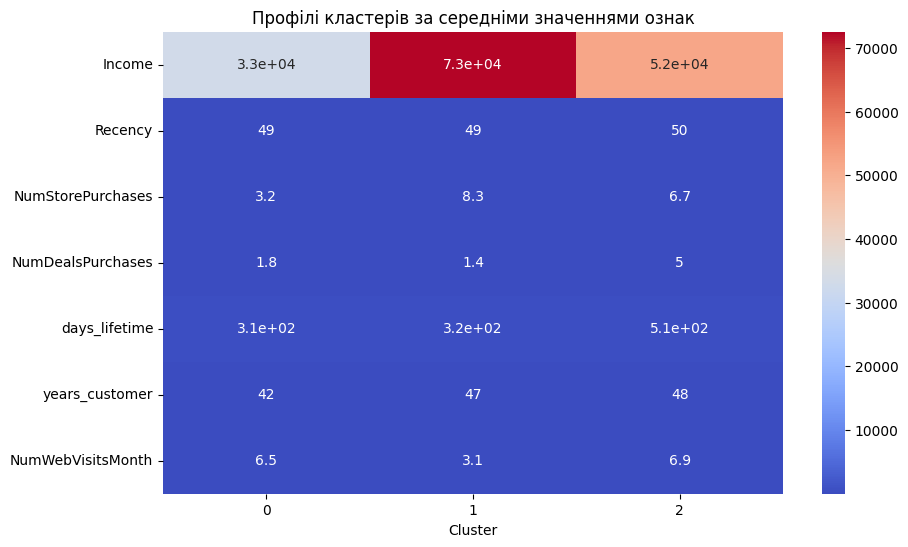

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile.T, annot=True, cmap="coolwarm")
plt.title("Профілі кластерів за середніми значеннями ознак")
plt.show()


**Кластер 0**\
Income ≈ 33k найнижчий дохід серед усіх.\
NumStorePurchases ≈ 3.2  рідко купують у магазинах.\
NumDealsPurchases ≈ 1.8  іноді реагують на знижки.\
NumWebVisitsMonth ≈ 6.5  активно заходять на сайт, але не завжди купують.\
days_lifetime ≈ 312, years_customer ≈ 42  клієнти з довгою історією, але низькою купівельною активністю.

**Інтерпретація:** це «довгожителі з низьким доходом» — вони давно з компанією, часто заходять на сайт, але купують мало. Можливо, їх варто стимулювати персональними пропозиціями.

**Кластер 1**
Income ≈ 72k найвищий дохід.\
NumStorePurchases ≈ 8.3 найбільш активні покупці в магазинах.\
NumDealsPurchases ≈ 1.4 мало реагують на знижки.\
NumWebVisitsMonth ≈ 3.1 рідко заходять на сайт.\
days_lifetime ≈ 315, years_customer ≈ 47 теж довгий життєвий цикл.

**Інтерпретація:** «преміум‑сегмент» — клієнти з високим доходом, які активно купують офлайн і не женуться за знижками.

**Кластер 2**
Income ≈ 52k середній дохід.\
NumStorePurchases ≈ 6.7 досить активні покупці.\
NumDealsPurchases ≈ 5.0 дуже часто купують зі знижками.\
NumWebVisitsMonth ≈ 6.9 активно відвідують сайт.\
days_lifetime ≈ 510, years_customer ≈ 48 найдовший життєвий цикл.

**Інтерпретація:** Клієнти із середнім доходом, які довго з компанією, активно відвідують сайт і роблять покупки переважно під час акцій.

Отже, іншими словами:

**Кластер 0** - формують клієнти з низьким доходом, малою кількістю покупок, але з довгим життєвим циклом і частими відвідуваннями сайту.

**Кластер 1** — це преміум‑сегмент із високим доходом і великою кількістю покупок у магазинах, які майже не реагують на знижки.

**Кластер 2** — клієнти із середнім доходом, які активно купують зі знижками, довго залишаються з компанією і часто заходять на сайт.

t‑SNE‑графік добре показав як дані групуються локально, та добре відобразив кластеризацію, оскільки він не лінійний. Як бачимо з графіку в нас завитушки кластерів.

У той час pca-графік добре показав розкид даних ключових змінних, але відобразити кластери не вийшло оскільки, метод лінійній і майже всі данні розташовані на одній лінії, тобто кластери ніби злилися один в одного.